In [398]:
import numpy as np # linear algebra
import matplotlib.pyplot as plt

In [399]:
g= 9.81
L = 1
dt = 0.01

In [400]:
X = np.array([[np.radians(30)], [0]])

F = np.array([
    [1, dt],
    [(-g/L)*dt, 1]
])

H = np.array([[1, 0]])

P = np.eye(2) * 1

Q = np.eye(2) * 0.001

R = 0.1

In [401]:
time = np.arange(0, 5, dt)
real_theta = []
mesured_theta = []
estimated_theta = []

In [402]:
curr_theta = np.radians(30)
curr_omega = 0

for t in time :
    accel = (-g/L)*np.sin(curr_theta)
    curr_omega += accel * dt
    curr_theta += curr_omega * dt

    z = curr_theta + np.random.normal(0, 0.1)

    X = F @ X
    P = F @ P @ F.T + Q
    
    y = z - (H @ X)
    S = H @ P @ H.T + R
    K = P @ H.T @ np.linalg.inv(S)
    X = X + K @ y
    P = (np.eye(2) - K @ H) @ P
    
    real_theta.append(np.degrees(curr_theta))
    mesured_theta.append(np.degrees(z))
    estimated_theta.append(np.degrees(X[0, 0]))

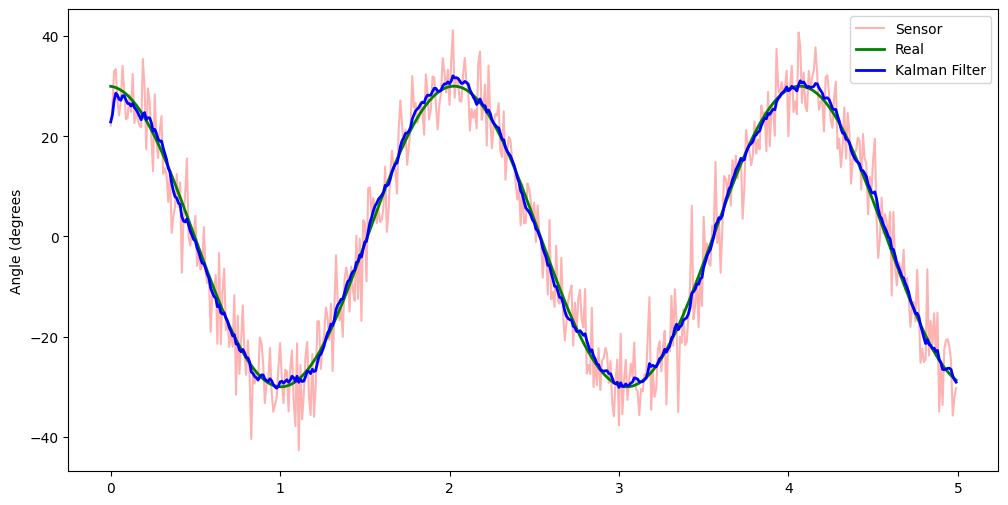

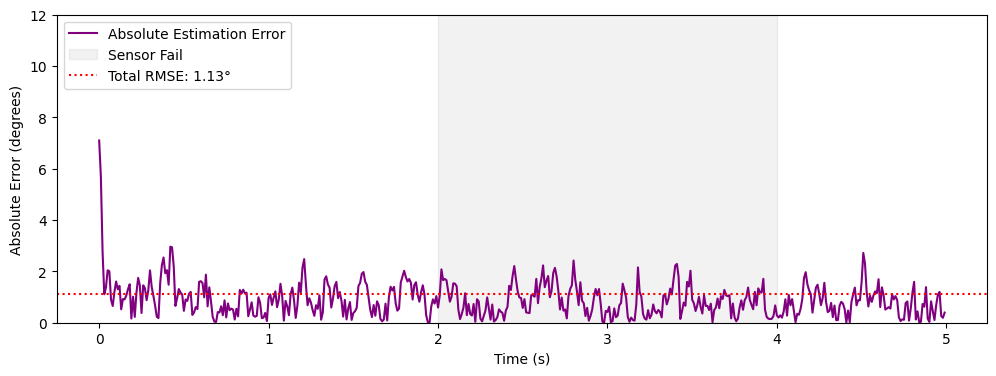

In [403]:
plt.figure(figsize = (12, 6))
plt.plot(time, mesured_theta, 'r', alpha = 0.3, label = 'Sensor')
plt.plot(time, real_theta, 'g', label = 'Real', linewidth = 2)
plt.plot(time, estimated_theta, 'b', label = 'Kalman Filter', linewidth = 2)
plt.ylabel('Angle (degrees')
plt.legend()
plt.show()

erro_abs = np.abs(np.array(real_theta) - np.array(estimated_theta))
rmse = np.sqrt(np.mean(erro_abs**2))

plt.figure(figsize=(12, 4))
plt.plot(t_arr, erro_abs, color='purple', label='Absolute Estimation Error')
plt.axvspan(2, 4, color='gray', alpha=0.1, label='Sensor Fail')
plt.axhline(y=rmse, color='red', linestyle=':', label=f'Total RMSE: {rmse:.2f}°')
plt.xlabel("Time (s)")
plt.ylabel("Absolute Error (degrees)")
plt.legend()
plt.ylim(0, 12)
plt.show()

In [404]:
estimated_theta = []
sensor_fail = []
real_theta = []
mesured_theta = []

for t in time :
    accel = (-g/L)*np.sin(curr_theta)
    curr_omega += accel * dt
    curr_theta += curr_omega * dt

    sensor_on = not(2<= t <= 4)

    X = F @ X
    P = F @ P @ F.T + Q
    
    z = np.nan
    if sensor_on:
        z = curr_theta + np.random.normal(0, 0.1)
        
        y = z - (H @ X)
        S = H @ P @ H.T + R
        K = P @ H.T @ np.linalg.inv(S)
        X = X + K @ y
        P = (np.eye(2) - K @ H) @ P

    sigma = np.sqrt(P[0, 0])
    
    real_theta.append(np.degrees(curr_theta))
    mesured_theta.append(np.degrees(z))
    estimated_theta.append(np.degrees(X[0, 0]))
    sensor_fail.append(np.degrees(sigma))

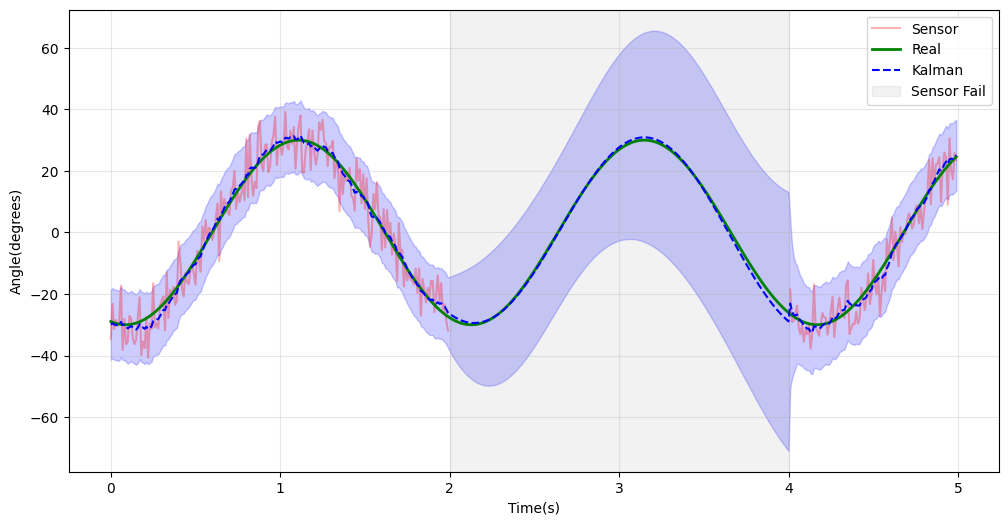

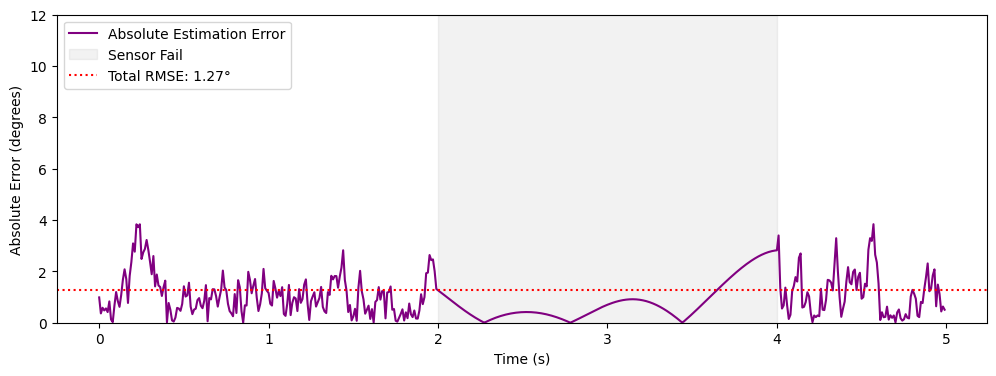

In [405]:
t_arr = np.array(time)
est = np.array(estimated_theta)
fail = np.array(sensor_fail)

plt.figure(figsize = (12, 6))
plt.fill_between(t_arr, est - 2*fail, est + 2*fail, color = 'blue', alpha = 0.2)
plt.plot(t_arr, mesured_theta, 'r', alpha = 0.3, label = "Sensor")
plt.plot(t_arr, real_theta, 'g-', label = "Real", linewidth = 2)
plt.plot(t_arr, est, 'b--', label = 'Kalman')
plt.axvspan(2, 4, color = 'gray', alpha = 0.1, label = 'Sensor Fail')
plt.xlabel("Time(s)")
plt.ylabel("Angle(degrees)")
plt.legend(loc='upper right')
plt.grid(True, alpha = 0.3)
plt.show()

erro_abs = np.abs(np.array(real_theta) - np.array(estimated_theta))
rmse = np.sqrt(np.mean(erro_abs**2))

plt.figure(figsize=(12, 4))
plt.plot(t_arr, erro_abs, color='purple', label='Absolute Estimation Error')
plt.axvspan(2, 4, color='gray', alpha=0.1, label='Sensor Fail')
plt.axhline(y=rmse, color='red', linestyle=':', label=f'Total RMSE: {rmse:.2f}°')
plt.xlabel("Time (s)")
plt.ylabel("Absolute Error (degrees)")
plt.legend()
plt.ylim(0, 12)
plt.show()


In [406]:
estimated_theta = []
sensor_fail = []
real_theta = []
mesured_theta = []

b = 0.5

for t in time :
    accel = (-g/L)*np.sin(curr_theta) - b*curr_omega
    curr_omega += accel * dt
    curr_theta += curr_omega * dt

    sensor_on = not (2<= t <= 4)

    X = F @ X
    P = F @ P @ F.T + Q

    z = np.nan
    if sensor_on :
        z = curr_theta + np.random.normal(0, 0.1)

        y = z - H @ X
        S = H @ P @ H.T + R
        K = P @ H.T @ np.linalg.inv(S)
        
        X = X + K @ y
        P = (np.eye(2) - K @ H) @ P

    sigma = np.sqrt(P[0, 0])

    real_theta.append(np.degrees(curr_theta))
    mesured_theta.append(np.degrees(z))
    estimated_theta.append(np.degrees(X[0,0]))
    sensor_fail.append(np.degrees(sigma))   

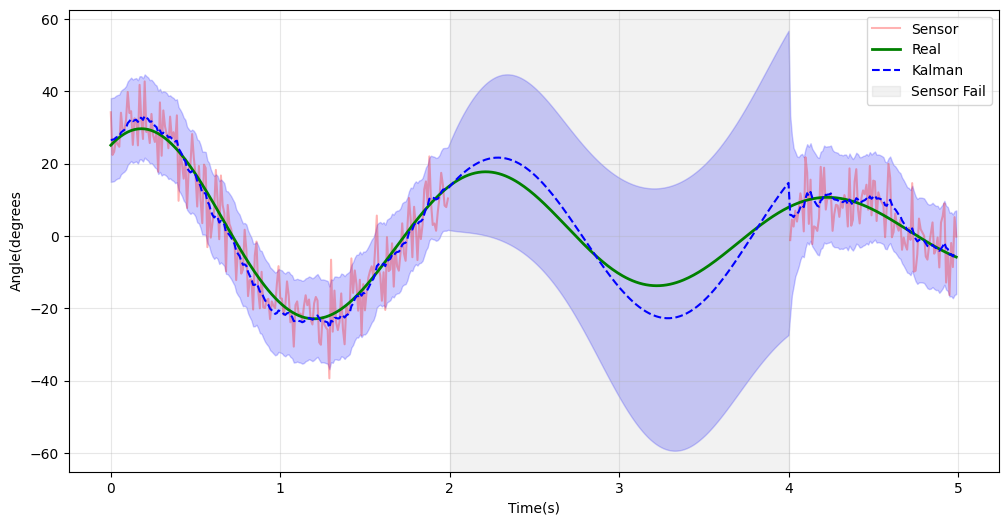

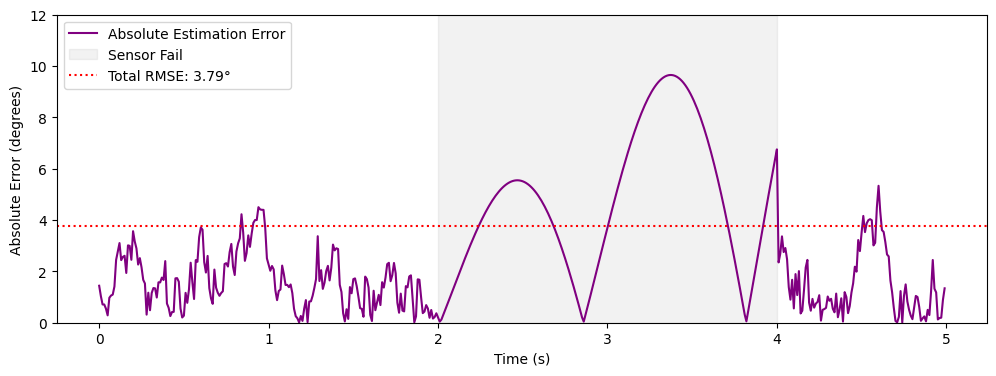

In [407]:
t_arr = np.array(time)
est = np.array(estimated_theta)
fail = np.array(sensor_fail)

plt.figure(figsize = (12,6))
plt.fill_between(t_arr, est - 2*fail, est + 2*fail, color = 'blue', alpha = 0.2)
plt.plot(t_arr, mesured_theta, 'r', alpha = 0.3, label = "Sensor")
plt.plot(t_arr, real_theta, 'g-', label = "Real", linewidth = 2)
plt.plot(t_arr, estimated_theta, 'b--', label = "Kalman")
plt.axvspan(2, 4, color = 'gray', alpha = 0.1, label = "Sensor Fail")
plt.xlabel("Time(s)")
plt.ylabel("Angle(degrees")
plt.legend(loc = "upper right")
plt.grid(True, alpha = 0.3)
plt.show()

erro_abs = np.abs(np.array(real_theta) - np.array(estimated_theta))
rmse = np.sqrt(np.mean(erro_abs**2))

plt.figure(figsize=(12, 4))
plt.plot(t_arr, erro_abs, color='purple', label='Absolute Estimation Error')
plt.axvspan(2, 4, color='gray', alpha=0.1, label='Sensor Fail')
plt.axhline(y=rmse, color='red', linestyle=':', label=f'Total RMSE: {rmse:.2f}°')
plt.xlabel("Time (s)")
plt.ylabel("Absolute Error (degrees)")
plt.legend()
plt.ylim(0, 12)
plt.show()